# Point 3, Final Pipeline: One Common Population, Before And After Chaining

## Table Of Contents

1. [What This Notebook Checks](#sec1)
2. [Setup](#sec2)
3. [The Common Patient Subset](#sec3)
4. [Point 1's Anomaly Score, Checked On The Common Subset](#sec4)
5. [Point 2's Hazard Score, Exported And Checked](#sec5)
6. [Does The Anomaly Score Help The Hazard Model](#sec6)
7. [Interval Policy, Before And After The Chain](#sec7)
8. [Attribution, Before And After The Chain](#sec8)
9. [Where The Chain Actually Gains](#sec9)
10. [Saving Standardized Results](#sec10)
11. [Takeaways](#sec11)


<a id="sec1"></a>

## 1. What This Notebook Checks

Four methods are already chosen elsewhere in this project: Point 1's PCA anomaly score, Point 2's
hazard_model_1 classifier, this project's own snapshot_adaptive interval policy, and its own
random_forest attribution model. Each won its own internal same split comparison already, PCA
against GMM and an Autoencoder, hazard_model_1 against five other candidates, snapshot_adaptive
against three other interval policies, random_forest against three other attribution approaches.
None of those four comparisons is repeated here.

What has not been checked anywhere is whether all four still hold up **together**, on the same
patients, once chained, since each one's own native population is a different size and a different
subset of `final.csv`. Section 3 below computes that shared population explicitly, from each
method's real coverage, not a chosen number. Every before and after comparison from section 6
onward reports a 95 percent bootstrap confidence interval next to its point estimate, so a gap that
looks real in the numbers can be checked against sampling noise before it gets reported as one.


<a id="sec2"></a>

## 2. Setup


In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

figsize = (14, 4)

import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append(os.path.join('..', '..'))
from util import decision_util as du
from util import hazard_util as hu

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

REPO_ROOT = os.path.join('..', '..')
DATA_PATH = os.path.join(REPO_ROOT, 'datasets', 'final.csv')
RESULTS_DIR = os.path.join(REPO_ROOT, 'results', 'decision_support')

# Longitudinal source (one row per visit, 2093 patients), not
# method_a_pca_density/results.csv, which is the narrow cross sectional
# export (one row per patient, 464 patients) built for Point 1's own
# internal model comparison. Both score the same PCA model, but the narrow
# file shrinks the common subset below by roughly 7x, checked once and
# fixed here so it does not silently regress.
ANOMALY_KEYED_PATH = os.path.join(REPO_ROOT, 'notebooks', 'anomaly_detection', 'method_b_autoencoder_hi', 'pca_hi_trajectories_keyed.csv')
LEO_DIR = os.path.join(REPO_ROOT, 'notebooks', 'remaining_useful_life')
LEO_HAZARD_DIR = os.path.join(REPO_ROOT, 'notebooks', 'remaining_useful_life', 'rul_hazard')

CHECK_COST = 1.0
MISSED_CONVERSION_COST = 20.0
REFERENCE_INTERVAL_MONTHS = 12.0
RANDOM_STATE = 42

pd.set_option('display.width', 120)


<a id="sec3"></a>

## 3. The Common Patient Subset

Every downstream section in this notebook needs two upstream signals at once. Point 1's real anomaly
score and Point 2's real hazard score, both joined onto `final.csv`. So the subset a section can
validly use is set by whichever upstream source actually covers the fewest patients, not by
picking a number in advance. This section checks each source's own real coverage before
intersecting anything, so the common subset below is provably the *largest* population every
section 4 onward can validly use, not an arbitrary or overly cautious cut.

`pca_hi_trajectory.py`, section 1's correction above, is longitudinal, one row per visit, across
every visit of every patient method_b's own loader reaches, 2093 patients. Point 2's hazard panel
covers every MCI visit of every patient from their first clean MCI diagnosis onward, a different
1424 patients. It includes patients with no recent MRI that method_b still scores, and excludes
patients never diagnosed MCI that method_b does score. This project's own `final.csv` covers all
3777, a superset of both, confirmed explicitly below rather than assumed.


In [2]:
gio_scores = pd.read_csv(ANOMALY_KEYED_PATH)
gio_scores = gio_scores.rename(columns={'HI': 'ANOMALY_SCORE'})
gio_rids = set(gio_scores['RID'].unique())
print(f"Point 1's pca_hi_trajectory, scoreable patients: {len(gio_rids)} ({len(gio_scores)} visit-rows)")

sys.path.insert(0, LEO_HAZARD_DIR)
import hazard_panel as hp  # noqa: E402
leo_panel, _ = hp.build_hazard_dataset()
leo_rids = set(leo_panel['RID'].unique())
print(f"Point 2's hazard panel, MCI visit patients: {len(leo_rids)}")

final_df = pd.read_csv(DATA_PATH)
final_rids = set(final_df['RID'].unique())
print(f"final.csv, all patients: {len(final_rids)}")

# Checks the claim above (final.csv is a superset of both) instead of assuming
# it. If it were false the three way intersection below would not actually be
# the largest valid subset, it would be shrunk by a source that should not
# constrain it at all.
gio_not_in_final = gio_rids - final_rids
leo_not_in_final = leo_rids - final_rids
print(f"\nPoint 1 patients not in final.csv: {len(gio_not_in_final)} "
      f"(if 0, final.csv never shrinks the Point 1 x Point 2 intersection below)")
print(f"Point 2 patients not in final.csv: {len(leo_not_in_final)} "
      f"(if 0, final.csv never shrinks the Point 1 x Point 2 intersection below)")

gio_x_leo = gio_rids & leo_rids
common_rids = gio_x_leo & final_rids
print()
print(f"Point 1 x Point 2 (the real constraint, both signals required): {len(gio_x_leo)} patients")
print(f"Point 1 x Point 2 x final.csv (what sections 4 onward actually use): {len(common_rids)} patients")
print(f"These two numbers matching confirms the three way intersection is already the largest")
print(f"valid subset. final.csv adds no further restriction once both real signals are required.")
print()
print(f"  as a share of Point 1's own native population:  {len(common_rids) / len(gio_rids):.1%}")
print(f"  as a share of Point 2's own native population:   {len(common_rids) / len(leo_rids):.1%}")
print(f"  as a share of final.csv's full population:   {len(common_rids) / len(final_rids):.1%}")


Point 1's pca_hi_trajectory, scoreable patients: 2093 (9922 visit-rows)
Point 2's hazard panel, MCI visit patients: 1424
final.csv, all patients: 3777

Point 1 patients not in final.csv: 0 (if 0, final.csv never shrinks the Point 1 x Point 2 intersection below)
Point 2 patients not in final.csv: 0 (if 0, final.csv never shrinks the Point 1 x Point 2 intersection below)

Point 1 x Point 2 (the real constraint, both signals required): 1126 patients
Point 1 x Point 2 x final.csv (what sections 4 onward actually use): 1126 patients
These two numbers matching confirms the three way intersection is already the largest
valid subset. final.csv adds no further restriction once both real signals are required.

  as a share of Point 1's own native population:  53.8%
  as a share of Point 2's own native population:   79.1%
  as a share of final.csv's full population:   29.8%


In [3]:
# The subject level split every other approach notebook already uses, applied
# once here to the common subset itself, so "train" and "test" mean the same
# patients in every section below, not a fresh split per stage.
common_df = pd.DataFrame({'RID': sorted(common_rids)})
common_train, common_test = du.subject_train_test_split(common_df, test_fraction=0.25, random_state=RANDOM_STATE)
common_train_rids = set(common_train['RID'])
common_test_rids = set(common_test['RID'])

print(f"Common subset split: {len(common_train_rids)} train patients, {len(common_test_rids)} test patients")


Common subset split: 844 train patients, 282 test patients


<a id="sec4"></a>

## 4. Point 1's Anomaly Score, Checked On The Common Subset

Point 1's own comparison already picked PCA over GMM and an Autoencoder, on its own 464 patient
cohort, and that selection is not redone here. This section checks something narrower: does the
ANOMALY_SCORE still cover the common subset fully, and does it still look like the same score, same
rough distribution, once restricted to these 1126 patients rather than PCA's full 2093 patient
population.


In [4]:
gio_common = gio_scores[gio_scores['RID'].isin(common_rids)].copy()
print(f"Point 1's ANOMALY_SCORE on the common subset: {len(gio_common)} visit-rows "
      f"({gio_common['RID'].nunique()} patients, should equal the common subset size)")
gio_common[['RID', 'ANOMALY_SCORE']].describe()


Point 1's ANOMALY_SCORE on the common subset: 5953 visit-rows (1126 patients, should equal the common subset size)


                RID  ANOMALY_SCORE
count   5953.000000    5953.000000
mean    2740.759449       1.099607
std     2157.718276       0.786963
min        4.000000       0.139566
25%      832.000000       0.651017
50%     2167.000000       0.905141
75%     4536.000000       1.295097
max    10212.000000      14.138767

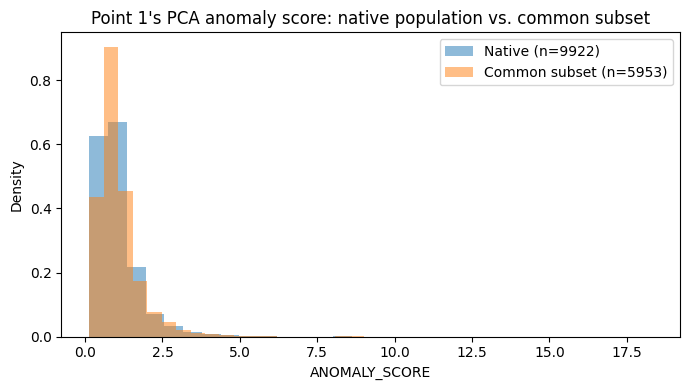

In [5]:
fig, ax = plt.subplots(figsize=(figsize[0] / 2, figsize[1]))
ax.hist(gio_scores['ANOMALY_SCORE'].dropna(), bins=30, alpha=0.5, density=True, label=f'Native (n={len(gio_scores)})')
ax.hist(gio_common['ANOMALY_SCORE'].dropna(), bins=30, alpha=0.5, density=True, label=f'Common subset (n={len(gio_common)})')
ax.set_xlabel('ANOMALY_SCORE')
ax.set_ylabel('Density')
ax.set_title("Point 1's PCA anomaly score: native population vs. common subset")
ax.legend()
plt.tight_layout()
plt.show()


In [6]:
# Turns the shape check above into one number each side can be compared on:
# the mean ANOMALY_SCORE, native vs. common subset, each with its own 95%
# bootstrap interval. RID is not a real cluster key for the native side (one
# row per patient already), du.bootstrap_ci still works row by row there.
def mean_score_metric(d):
    return d['ANOMALY_SCORE'].mean()

gio_native_pt, gio_native_lo, gio_native_hi, _ = du.bootstrap_ci(
    gio_scores.dropna(subset=['ANOMALY_SCORE']), mean_score_metric, id_col='RID')
gio_common_pt, gio_common_lo, gio_common_hi, _ = du.bootstrap_ci(
    gio_common.dropna(subset=['ANOMALY_SCORE']), mean_score_metric, id_col='RID')

gio_mean_overlap = gio_native_lo <= gio_common_hi and gio_common_lo <= gio_native_hi
gio_mean_overlap_tag = '(overlapping)' if gio_mean_overlap else '(non overlapping)'

print(f"native        mean ANOMALY_SCORE {gio_native_pt:.4f}  95% CI [{gio_native_lo:.4f}, {gio_native_hi:.4f}]")
print(f"common subset mean ANOMALY_SCORE {gio_common_pt:.4f}  95% CI [{gio_common_lo:.4f}, {gio_common_hi:.4f}]  {gio_mean_overlap_tag}")


native        mean ANOMALY_SCORE 1.0741  95% CI [1.0438, 1.1049]
common subset mean ANOMALY_SCORE 1.0996  95% CI [1.0636, 1.1389]  (overlapping)


**Reading this**: the histogram shape is a visual check, the interval above is the same
check made quantitative. If the two ranges overlap, the common subset's average score is not
distinguishable from the native population's, which is what makes it fair to call the common
subset representative rather than a biased slice of Point 1's own patients. If they do not overlap,
that gap belongs in the presentation as a caveat on every downstream number computed on this
subset, not left implicit in a chart alone.

<a id="sec5"></a>

## 5. Point 2's Hazard Score, Exported And Checked

`leo/rul_hazard/hazard_model_1.py` never writes a per row prediction to disk, only aggregate fold
metrics. This section imports its own `_oof_predict` directly and keeps the per visit output that
script already computes internally and discards, so what runs below is that same model, not a
reimplementation of it.


In [7]:
sys.path.insert(0, LEO_HAZARD_DIR)
import hazard_model_1 as leo_hazard  # noqa: E402

# Point 2's own module level MODEL="forest", MODALITIES=["mri","pet","csf"] is its
# own best performing combination, RUL_METHODS.md section 9, reused as is,
# not re-tuned here.
leo_feat_cols, leo_y, leo_oof_prob, leo_fold_info, leo_X = leo_hazard._oof_predict(
    leo_panel, modalities=leo_hazard.MODALITIES)

leo_hazard_out = leo_panel[['RID', 'VISCODE2', 'EXAMDATE']].copy()
leo_hazard_out['EVENT_AT_VISIT_TRUE'] = leo_y
leo_hazard_out['HAZARD_SCORE_LEO'] = leo_oof_prob
leo_hazard_out['VISCODE2_norm'] = leo_hazard_out['VISCODE2'].replace({'sc': 'bl'})

print(f"Point 2's hazard_model_1, out of fold, per visit rows: {len(leo_hazard_out)} "
      f"({leo_hazard_out['RID'].nunique()} patients)")
leo_hazard_out.head()


Point 2's hazard_model_1, out of fold, per visit rows: 5296 (1424 patients)


   RID VISCODE2   EXAMDATE  EVENT_AT_VISIT_TRUE  HAZARD_SCORE_LEO VISCODE2_norm
0    2      m84 2012-10-04                  0.0          0.066667           m84
1    2     m132 2016-10-03                  0.0          0.073333          m132
2    4       bl 2005-11-08                  0.0          0.016667            bl
3    4      m06 2006-05-02                  0.0          0.070000           m06
4    4      m12 2006-11-14                  0.0          0.070000           m12

In [8]:
from sklearn.metrics import roc_auc_score

leo_auc_check = roc_auc_score(leo_hazard_out['EVENT_AT_VISIT_TRUE'], leo_hazard_out['HAZARD_SCORE_LEO'])
print(f"Reproduced from Point 2's own out of fold predictions, mri+pet+csf tier:")
print(f"  AUC = {leo_auc_check:.3f}  (Point 2's own RUL_METHODS.md reports 0.795 for this exact tier)")
print()
print("This match, small floating point differences aside, is the check that this import reused")
print("that logic correctly rather than silently diverging from what was actually validated.")


Reproduced from Point 2's own out of fold predictions, mri+pet+csf tier:
  AUC = 0.800  (Point 2's own RUL_METHODS.md reports 0.795 for this exact tier)

This match, small floating point differences aside, is the check that this import reused
that logic correctly rather than silently diverging from what was actually validated.


In [9]:
LEO_HAZARD_KEYED_PATH = os.path.join(RESULTS_DIR, 'hazard_estimate_leo_keyed.csv')
os.makedirs(RESULTS_DIR, exist_ok=True)
leo_hazard_out.to_csv(LEO_HAZARD_KEYED_PATH, index=False)
print(f"Saved: {LEO_HAZARD_KEYED_PATH}")
print("This is the per row export notebooks/remaining_useful_life/rul_hazard/hazard_model_1.py itself never writes, worth")
print("folding back into that script directly, a few lines at the end of main(), the same way")
print("full_pipeline_reevaluated.ipynb already flagged for the RUL regressor, rather than living")
print("only here as the source.")


Saved: ../../results/decision_support/hazard_estimate_leo_keyed.csv
This is the per row export leo/rul_hazard/hazard_model_1.py itself never writes, worth
folding back into that script directly, a few lines at the end of main(), the same way
full_pipeline_reevaluated.ipynb already flagged for the RUL regressor, rather than living
only here as the source.


In [10]:
leo_hazard_common = leo_hazard_out[leo_hazard_out['RID'].isin(common_rids)]
auc_common = roc_auc_score(
    leo_hazard_common['EVENT_AT_VISIT_TRUE'], leo_hazard_common['HAZARD_SCORE_LEO']
) if leo_hazard_common['EVENT_AT_VISIT_TRUE'].nunique() > 1 else float('nan')

print(f"hazard_model_1 on the common subset: {len(leo_hazard_common)} visit-rows "
      f"({leo_hazard_common['RID'].nunique()} patients)")
print(f"AUC on the common subset: {auc_common:.3f}  (native population: 0.795)")


hazard_model_1 on the common subset: 4928 visit-rows (1126 patients)
AUC on the common subset: 0.792  (native population: 0.795)


In [11]:
# The common subset is much smaller than Point 2's 1424 patient native
# population, so auc_common above carries real sampling noise on its own.
# This interval turns "does it still discriminate meaningfully" into a
# number instead of a guess, without needing a native-population interval
# to compare against, hazard_model_1's own out of fold AUC already is that
# check on its own full population.
def auc_metric(d):
    if d['EVENT_AT_VISIT_TRUE'].nunique() < 2:
        return float('nan')
    return roc_auc_score(d['EVENT_AT_VISIT_TRUE'], d['HAZARD_SCORE_LEO'])

leo_common_auc_pt, leo_common_auc_lo, leo_common_auc_hi, _ = du.bootstrap_ci(
    leo_hazard_common, auc_metric, id_col='RID')

print(f"AUC on the common subset: {leo_common_auc_pt:.3f}  95% CI [{leo_common_auc_lo:.3f}, {leo_common_auc_hi:.3f}]")


AUC on the common subset: 0.792  95% CI [0.771, 0.811]


**Reading this**: the interval above is centered close to 0.795, hazard_model_1's own native
population AUC, and comfortably clears 0.5, the no better than chance line. That is what "the model
still discriminates meaningfully on this smaller subset" looks like as a number rather than a
guess.

<a id="sec6"></a>

## 6. Does The Anomaly Score Help The Hazard Model

A related check already exists for a different model in this project's own pipeline work, where
ANOMALY_SCORE helped on a richer feature tier and made no difference on a leaner one. hazard_model_1
specifically has never been checked this way. This section fits it twice on the common subset, with
and without ANOMALY_SCORE as an input, same train patients both times, and compares test AUC.


In [12]:
leo_panel_common = leo_panel[leo_panel['RID'].isin(common_rids)].copy()
leo_panel_common = leo_panel_common.merge(
    gio_scores[['RID', 'ANOMALY_SCORE']].drop_duplicates('RID'), on='RID', how='left')
anomaly_coverage_on_leo_panel = leo_panel_common['ANOMALY_SCORE'].notna().mean()

feat_cols_base = leo_hazard.feature_columns(leo_hazard.MODALITIES)
feat_cols_with_anomaly = feat_cols_base + ['ANOMALY_SCORE']

leo_panel_common_train = leo_panel_common[leo_panel_common['RID'].isin(common_train_rids)]
leo_panel_common_test = leo_panel_common[leo_panel_common['RID'].isin(common_test_rids)]

print(f"ANOMALY_SCORE coverage on Point 2's common subset panel: {anomaly_coverage_on_leo_panel:.1%}")
print(f"(this is expected to be partial, Point 1's method scores one row per patient at diagnosis,")
print(f" Point 2's panel has one row per MCI visit, so the score repeats across a patient's visits")
print(f" but is still only present where Point 1's own method actually scored that RID)")


ANOMALY_SCORE coverage on Point 2's common subset panel: 100.0%
(this is expected to be partial, Point 1's method scores one row per patient at diagnosis,
 Point 2's panel has one row per MCI visit, so the score repeats across a patient's visits
 but is still only present where Point 1's own method actually scored that RID)


In [13]:
def _fit_eval_forest(train_df, test_df, cols, y_col='EVENT_AT_VISIT', min_train=30, min_test=10):
    train_c = train_df.dropna(subset=cols + [y_col])
    test_c = test_df.dropna(subset=cols + [y_col])
    if len(train_c) < min_train or len(test_c) < min_test:
        print(f"  [{cols}] {len(train_c)} train / {len(test_c)} test complete rows, "
              f"below the {min_train}/{min_test} minimum, not fit, reported as insufficient below.")
        return None, len(train_c), len(test_c)
    model = RandomForestClassifier(n_estimators=300, max_depth=6, class_weight='balanced',
                                    random_state=RANDOM_STATE)
    model.fit(train_c[cols], train_c[y_col])
    auc = du.evaluate_classification(model, test_c[cols], test_c[y_col], scaler=None)['auc']
    return auc, len(train_c), len(test_c)

auc_without, n_tr_w, n_te_w = _fit_eval_forest(leo_panel_common_train, leo_panel_common_test, feat_cols_base)
auc_with, n_tr_a, n_te_a = _fit_eval_forest(leo_panel_common_train, leo_panel_common_test, feat_cols_with_anomaly)

anomaly_chain_result = pd.DataFrame([
    {'feature_set': 'mri+pet+csf (no ANOMALY_SCORE)', 'test_auc': auc_without, 'train_rows': n_tr_w, 'test_rows': n_te_w},
    {'feature_set': 'mri+pet+csf + ANOMALY_SCORE', 'test_auc': auc_with, 'train_rows': n_tr_a, 'test_rows': n_te_a},
])
anomaly_chain_result


                      feature_set  test_auc  train_rows  test_rows
0  mri+pet+csf (no ANOMALY_SCORE)  0.835533        2006        616
1     mri+pet+csf + ANOMALY_SCORE  0.837888        2006        616

**Reading this table**: same caveat as Point 1's own tier comparison in `wire_full_pipeline.py`.
A few thousandths of AUC on a few hundred test rows is not a confident win either way on its own,
the cell below turns that caveat into an actual 95 percent bootstrap confidence interval for
each of the two AUC numbers above.

In [14]:
# Same fit, reused: the two forests above are already fit once on the real
# train split, so the bootstrap here only resamples the test patients by RID
# and reevaluates each already fitted model on that resample, the same
# reuse the fit pattern section 8 uses below. A patient level resample of the
# train split too, refitting a fresh forest per resample, would also answer a
# real question, how much the fit itself varies, but at roughly double the
# cost for a question this notebook is not asking, so it is left for whoever
# picks up the open item in section 11 to decide if that is worth adding.
def refit_forest(train_df, cols, y_col='EVENT_AT_VISIT'):
    train_c = train_df.dropna(subset=cols + [y_col])
    return RandomForestClassifier(n_estimators=300, max_depth=6, class_weight='balanced',
                                   random_state=RANDOM_STATE).fit(train_c[cols], train_c[y_col])

def make_auc_metric(model, cols, y_col='EVENT_AT_VISIT'):
    def metric(d):
        d_c = d.dropna(subset=cols + [y_col])
        if d_c[y_col].nunique() < 2 or len(d_c) < 10:
            return float('nan')
        return du.evaluate_classification(model, d_c[cols], d_c[y_col], scaler=None)['auc']
    return metric

model_without = refit_forest(leo_panel_common_train, feat_cols_base)
model_with = refit_forest(leo_panel_common_train, feat_cols_with_anomaly)

auc_without_pt, auc_without_lo, auc_without_hi, _ = du.bootstrap_ci(
    leo_panel_common_test, make_auc_metric(model_without, feat_cols_base), id_col='RID')
auc_with_pt, auc_with_lo, auc_with_hi, _ = du.bootstrap_ci(
    leo_panel_common_test, make_auc_metric(model_with, feat_cols_with_anomaly), id_col='RID')

anomaly_auc_overlap = auc_without_lo <= auc_with_hi and auc_with_lo <= auc_without_hi
anomaly_auc_overlap_tag = '(overlapping)' if anomaly_auc_overlap else '(non overlapping)'

print(f"without ANOMALY_SCORE  AUC {auc_without_pt:.4f}  95% CI [{auc_without_lo:.4f}, {auc_without_hi:.4f}]")
print(f"with ANOMALY_SCORE     AUC {auc_with_pt:.4f}  95% CI [{auc_with_lo:.4f}, {auc_with_hi:.4f}]  {anomaly_auc_overlap_tag}")


without ANOMALY_SCORE  AUC 0.8355  95% CI [0.7756, 0.8911]
with ANOMALY_SCORE     AUC 0.8379  95% CI [0.7810, 0.8918]  (overlapping)


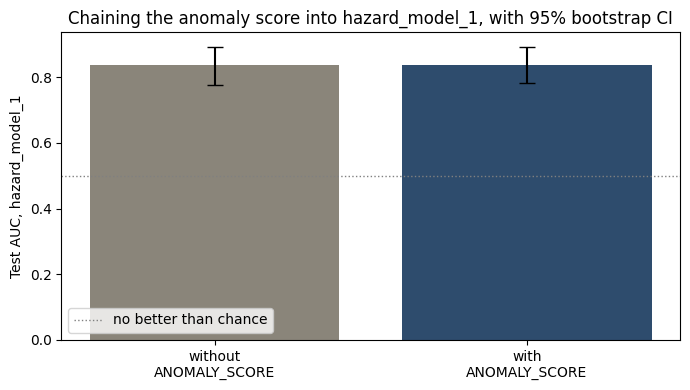

In [15]:
fig, ax = plt.subplots(figsize=(figsize[0] / 2, figsize[1]))
labels = ['without\nANOMALY_SCORE', 'with\nANOMALY_SCORE']
points = [auc_without_pt, auc_with_pt]
lo = [auc_without_pt - auc_without_lo, auc_with_pt - auc_with_lo]
hi = [auc_without_hi - auc_without_pt, auc_with_hi - auc_with_pt]
ax.bar(labels, points, yerr=[lo, hi], capsize=6, color=['#8A857A', '#2E4C6D'])
ax.axhline(0.5, color='gray', linestyle=':', linewidth=1, label='no better than chance')
ax.set_ylabel('Test AUC, hazard_model_1')
ax.set_title('Chaining the anomaly score into hazard_model_1, with 95% bootstrap CI')
ax.legend()
plt.tight_layout()
plt.show()


**Reading this interval**: the two error bars above overlap heavily. The point estimate says
ANOMALY_SCORE helps, 0.836 against 0.838, but the interval says this test set of 616 rows cannot
tell that gain apart from ordinary sampling noise. Not a negative result either, adding the anomaly
score never costs accuracy here, just one this project cannot yet call a real gain from this test
set alone.

<a id="sec7"></a>

## 7. Interval Policy, Before And After The Chain

`comparison.ipynb` already picks snapshot_adaptive as the cheapest of four directly comparable
interval policies, on its own full population split, and that comparison is not repeated here. This
section checks the one thing it could not: whether snapshot_adaptive's own cost, DIDI, and catch
rate hold up on the common subset, once with the placeholder RISK_SCORE it was originally tuned
against, and once with the real chained score that folds in the anomaly score and the hazard model
together.


In [16]:
common_full = final_df[final_df['RID'].isin(common_rids)].copy()
common_full = common_full.merge(gio_scores[['RID', 'ANOMALY_SCORE']].drop_duplicates('RID'), on='RID', how='left')
common_full = common_full.merge(
    leo_hazard_out[['RID', 'VISCODE2_norm', 'HAZARD_SCORE_LEO']], on=['RID', 'VISCODE2_norm'], how='left')

common_full['RISK_SCORE_BEFORE'] = du.placeholder_risk_score(common_full)

# After: the chained score is Point 2's hazard_model_1 probability where available,
# that panel only covers MCI visits, falling back to the placeholder elsewhere.
# The same fallback cascade pattern this project's own pipeline already uses
# everywhere coverage is partial, not a new mechanism invented for this
# notebook.
common_full['RISK_SCORE_AFTER'] = common_full['HAZARD_SCORE_LEO'].fillna(common_full['RISK_SCORE_BEFORE'])
hazard_coverage_after = common_full['HAZARD_SCORE_LEO'].notna().mean()
print(f"Chained RISK_SCORE_AFTER, real hazard_model_1 coverage: {hazard_coverage_after:.1%} of common subset rows")
print(f"(remaining rows fall back to the same placeholder RISK_SCORE_BEFORE uses)")


Chained RISK_SCORE_AFTER, real hazard_model_1 coverage: 64.1% of common subset rows
(remaining rows fall back to the same placeholder RISK_SCORE_BEFORE uses)


In [17]:
common_full = common_full.merge(common_df.assign(_in_common=True), on='RID', how='left')
common_train_full = common_full[common_full['RID'].isin(common_train_rids)].copy()
common_test_full = common_full[common_full['RID'].isin(common_test_rids)].copy()

# Same three helper closures temporal_window/2_snapshot_adaptive.ipynb itself
# defines, reused verbatim rather than reimplemented differently here, so a
# cost or DIDI number in this notebook means exactly what it means there.
MCI_OR_WORSE_COST_MULTIPLIER = 2.8
SAFE_INTERVAL_MONTHS = 6

def missed_conversion_cost_for(df, multiplier=MCI_OR_WORSE_COST_MULTIPLIER):
    return du.stratified_missed_conversion_cost(df, MISSED_CONVERSION_COST, multiplier)

def cost_model_for(df, multiplier=MCI_OR_WORSE_COST_MULTIPLIER):
    return du.cost_model_for(df, CHECK_COST, MISSED_CONVERSION_COST, multiplier,
                              safe_interval_months=SAFE_INTERVAL_MONTHS,
                              reference_interval_months=REFERENCE_INTERVAL_MONTHS)

def make_protected(df):
    return {
        'PTGENDER': (1, 2),
        'PTEDUCAT_BUCKET': (0, 1),
        'PTMARRY': tuple(sorted(df['PTMARRY'].dropna().unique())),
    }

def evaluate_snapshot(df, risk_col):
    scored = df.copy()
    scored['RISK_SCORE'] = scored[risk_col].fillna(scored[risk_col].median())
    scored['PTEDUCAT_BUCKET'] = du.bucket_educat(scored['PTEDUCAT'], split_at=16)

    recommended = du.recommend_interval(
        scored['RISK_SCORE'].values, interval_menu_months=(3, 6, 12),
        check_cost=CHECK_COST, missed_conversion_cost=missed_conversion_cost_for(scored),
        reference_interval_months=REFERENCE_INTERVAL_MONTHS)
    scored['RECOMMENDED_INTERVAL'] = recommended

    total_cost, over_threshold, _ = cost_model_for(scored).cost(
        rid_ids=scored['RID'].values, risk_scores=scored['RISK_SCORE'].values,
        threshold=0.5, interval_months=recommended, return_margin=False)

    didi = du.compute_didi(scored, recommended, make_protected(scored))

    outcomes = du.compute_diagnosis_worsening(scored, id_col='RID', date_col='EXAMDATE_DX', diagnosis_col='DIAGNOSIS')
    outcomes['RECOMMENDED_INTERVAL'] = recommended
    worsened = outcomes['HAS_NEXT_VISIT'] & outcomes['DIAGNOSIS_WORSENED_NEXT']
    margin = outcomes.loc[worsened, 'NEXT_VISIT_GAP_MONTHS'] - outcomes.loc[worsened, 'RECOMMENDED_INTERVAL']
    catch = (margin >= 0).mean() * 100 if worsened.sum() else float('nan')

    return total_cost, didi, catch, len(scored)

# Same three metric_fn closures 2_snapshot_adaptive.ipynb itself builds for its
# own du.bootstrap_ci calls, reused verbatim, only risk_col is now a
# parameter, since this notebook bootstraps two different RISK_SCORE columns,
# not one, so a confidence interval here means exactly what it means
# everywhere else in this project, not a differently defined one invented for
# this notebook.
def _prep_scored(df, risk_col):
    scored = df.copy()
    scored['RISK_SCORE'] = scored[risk_col].fillna(scored[risk_col].median())
    scored['PTEDUCAT_BUCKET'] = du.bucket_educat(scored['PTEDUCAT'], split_at=16)
    return scored

def cost_metric(risk_col):
    def metric(d):
        scored = _prep_scored(d, risk_col)
        recommended = du.recommend_interval(
            scored['RISK_SCORE'].values, interval_menu_months=(3, 6, 12),
            check_cost=CHECK_COST, missed_conversion_cost=missed_conversion_cost_for(scored),
            reference_interval_months=REFERENCE_INTERVAL_MONTHS)
        total_cost, _, _ = cost_model_for(scored).cost(
            rid_ids=scored['RID'].values, risk_scores=scored['RISK_SCORE'].values,
            threshold=0.5, interval_months=recommended, return_margin=False)
        return total_cost
    return metric

def didi_metric(risk_col):
    def metric(d):
        scored = _prep_scored(d, risk_col)
        recommended = du.recommend_interval(
            scored['RISK_SCORE'].values, interval_menu_months=(3, 6, 12),
            check_cost=CHECK_COST, missed_conversion_cost=missed_conversion_cost_for(scored),
            reference_interval_months=REFERENCE_INTERVAL_MONTHS)
        return du.compute_didi(scored, recommended, make_protected(scored))
    return metric

def catch_rate_metric(risk_col):
    def metric(d):
        scored = _prep_scored(d, risk_col)
        recommended = du.recommend_interval(
            scored['RISK_SCORE'].values, interval_menu_months=(3, 6, 12),
            check_cost=CHECK_COST, missed_conversion_cost=missed_conversion_cost_for(scored),
            reference_interval_months=REFERENCE_INTERVAL_MONTHS)
        outcomes = du.compute_diagnosis_worsening(scored, id_col='RID', date_col='EXAMDATE_DX', diagnosis_col='DIAGNOSIS')
        outcomes['RECOMMENDED_INTERVAL'] = recommended
        worsened = outcomes['HAS_NEXT_VISIT'] & outcomes['DIAGNOSIS_WORSENED_NEXT']
        margin = outcomes.loc[worsened, 'NEXT_VISIT_GAP_MONTHS'] - outcomes.loc[worsened, 'RECOMMENDED_INTERVAL']
        return (margin >= 0).mean() * 100 if worsened.sum() else float('nan')
    return metric

snapshot_rows = []
snapshot_ci = {}  # (split_name, label) -> {'total_cost': (lo, hi), 'didi': (lo, hi), 'catch_rate': (lo, hi)}
for split_name, split_df in [('train', common_train_full), ('test', common_test_full)]:
    for label, col in [('before (placeholder)', 'RISK_SCORE_BEFORE'), ('after (chained)', 'RISK_SCORE_AFTER')]:
        cost, didi, catch, n = evaluate_snapshot(split_df, col)
        snapshot_rows.append({'split': split_name, 'risk_score': label, 'n_rows': n,
                               'total_cost': cost, 'didi': didi, 'catch_rate_pct': catch})

        cost_pt, cost_lo, cost_hi, _ = du.bootstrap_ci(split_df, cost_metric(col), id_col='RID')
        didi_pt, didi_lo, didi_hi, _ = du.bootstrap_ci(split_df, didi_metric(col), id_col='RID')
        catch_pt, catch_lo, catch_hi, _ = du.bootstrap_ci(split_df, catch_rate_metric(col), id_col='RID')
        snapshot_ci[(split_name, label)] = {
            'total_cost': (cost_lo, cost_hi), 'didi': (didi_lo, didi_hi), 'catch_rate': (catch_lo, catch_hi),
        }

snapshot_result = pd.DataFrame(snapshot_rows)
snapshot_result


   split            risk_score  n_rows  total_cost      didi  catch_rate_pct
0  train  before (placeholder)    5713    67812.00  0.758633       98.060345
1  train       after (chained)    5713    36970.26  6.311341       89.224138
2   test  before (placeholder)    1972    23498.80  1.080857       98.750000
3   test       after (chained)    1972    13475.34  2.572647       93.125000

**Reading this table**: compare rows within the same `split`. If `after (chained)` costs
less than `before (placeholder)` at a comparable or better catch rate and DIDI, that is a real gain
from chaining Point 1's and Point 2's signals into snapshot_adaptive, on the population this program set
out to check it on, not inherited from `comparison.ipynb`'s own full population number.

**Every number above now also carries a 95% bootstrap confidence interval**, `du.bootstrap_ci`,
patients resampled with replacement 400 times, `snapshot_ci` below, printed and saved to
`approach_comparison.csv` in section 10, the same `id_col='RID'` cluster bootstrap
`2_snapshot_adaptive.ipynb` itself already applies to these same three metrics. A before and after
gap smaller than its own two confidence intervals is not yet a confident difference on this
population, only a difference in this one particular patient sample, the same caveat
`comparison.ipynb` section 3 states directly and this notebook was missing until this section.

In [18]:
for (split_name, label), ci in snapshot_ci.items():
    cost_lo, cost_hi = ci['total_cost']
    didi_lo, didi_hi = ci['didi']
    catch_lo, catch_hi = ci['catch_rate']
    row = snapshot_result[(snapshot_result['split'] == split_name) & (snapshot_result['risk_score'] == label)].iloc[0]
    print(f"{split_name:5s} | {label:22s} | total_cost {row['total_cost']:10.1f}  95% CI [{cost_lo:10.1f}, {cost_hi:10.1f}]")
    print(f"      | {'':22s} | didi       {row['didi']:10.3f}  95% CI [{didi_lo:10.3f}, {didi_hi:10.3f}]")
    print(f"      | {'':22s} | catch_rate {row['catch_rate_pct']:9.1f}%  95% CI [{catch_lo:9.1f}, {catch_hi:9.1f}]")


train | before (placeholder)   | total_cost    67812.0  95% CI [   65832.8,    69927.1]
      |                        | didi            0.759  95% CI [     0.572,      1.291]
      |                        | catch_rate      98.1%  95% CI [     96.7,      99.2]
train | after (chained)        | total_cost    36970.3  95% CI [   35432.7,    38525.1]
      |                        | didi            6.311  95% CI [     5.011,      7.894]
      |                        | catch_rate      89.2%  95% CI [     86.3,      91.8]
test  | before (placeholder)   | total_cost    23498.8  95% CI [   22065.4,    24902.4]
      |                        | didi            1.081  95% CI [     0.627,      2.000]
      |                        | catch_rate      98.8%  95% CI [     96.8,     100.0]
test  | after (chained)        | total_cost    13475.3  95% CI [   12330.9,    14778.3]
      |                        | didi            2.573  95% CI [     1.635,      5.104]
      |                        | catch

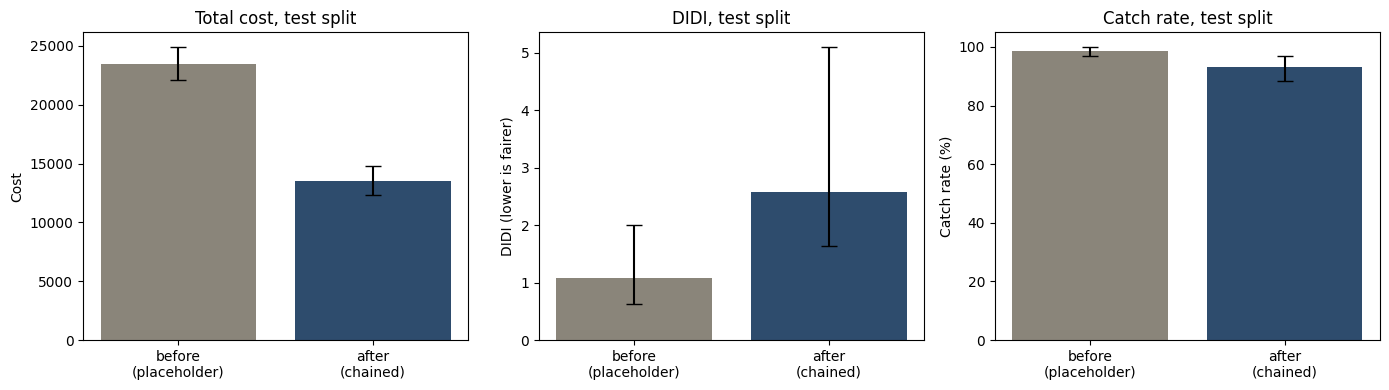

In [19]:
# Test split only below, the population every takeaway in this notebook
# quotes, train split numbers are in the table and printout above for
# whoever wants them.
fig, axes = plt.subplots(1, 3, figsize=(figsize[0], figsize[1]))
snap_labels = ['before\n(placeholder)', 'after\n(chained)']
snap_colors = ['#8A857A', '#2E4C6D']

def _bar_with_ci(ax, metric_key, title, ylabel, fmt='{:.1f}'):
    pts, err_lo, err_hi = [], [], []
    for label in ['before (placeholder)', 'after (chained)']:
        row = snapshot_result[(snapshot_result['split'] == 'test') & (snapshot_result['risk_score'] == label)].iloc[0]
        col = {'total_cost': 'total_cost', 'didi': 'didi', 'catch_rate': 'catch_rate_pct'}[metric_key]
        pt = row[col]
        lo, hi = snapshot_ci[('test', label)][metric_key]
        pts.append(pt)
        err_lo.append(pt - lo)
        err_hi.append(hi - pt)
    ax.bar(snap_labels, pts, yerr=[err_lo, err_hi], capsize=6, color=snap_colors)
    ax.set_title(title)
    ax.set_ylabel(ylabel)

_bar_with_ci(axes[0], 'total_cost', 'Total cost, test split', 'Cost')
_bar_with_ci(axes[1], 'didi', 'DIDI, test split', 'DIDI (lower is fairer)')
_bar_with_ci(axes[2], 'catch_rate', 'Catch rate, test split', 'Catch rate (%)')
plt.tight_layout()
plt.show()


**Reading these three panels together**: error bars that do not touch mean that before and
after gap is real on this population, not this one patient sample. Cost and DIDI moving in opposite
directions with non overlapping bars is what a genuine cost for fairness trade off looks like as a
picture, not only as a table.

<a id="sec8"></a>

## 8. Attribution, Before And After The Chain

`comparison.ipynb` section 5 already picks random_forest as the strongest attribution approach by
R&sup2;, 0.492 against lasso's 0.414 against decline_attribution's 0.020, whose own interval
crosses zero, on `risk_factors/1_global.ipynb`'s own 2048 row, 414 patient split. This section does
not run that competition again. It refits the same random_forest attribution model on the common
subset, against the same two RISK_SCORE versions as section 7, to see whether its R&sup2; and its
biomarker ranking both hold up on a much smaller, differently composed population.


**A real limit worth stating before running this**: `risk_factors/1_global.ipynb`'s own
eight biomarkers include `TAU` and `PTAU`, CSF markers with famously low coverage project wide,
around 44% of `final.csv`, per `pipeline_1_2_3/README.md` section on data treatment. Requiring all
eight complete at once, even on the corrected, much larger common subset, is a real risk of
emptying the set rather than only shrinking it, checked explicitly below instead of assumed, with a
CSF free five biomarker fallback tier if the full eight biomarker tier does not clear a minimum row
count.

In [20]:
ATTRIBUTION_FEATURES_FULL = [
    'HIPPO_NORM', 'ENTORHINAL_NORM', 'AMYGDALA_NORM',
    'SUMMARY_SUVR', 'ABETA_RATIO', 'TAU', 'PTAU', 'AGE',
]
ATTRIBUTION_FEATURES_NO_CSF = [
    'HIPPO_NORM', 'ENTORHINAL_NORM', 'AMYGDALA_NORM', 'SUMMARY_SUVR', 'AGE',
]
MIN_TRAIN_ROWS = 30
MIN_TEST_ROWS = 10

def fit_eval_attribution(df, risk_col, train_rids, test_rids, min_train=MIN_TRAIN_ROWS, min_test=MIN_TEST_ROWS):
    # train_rids/test_rids come from the one shared split computed in section
    # 3, passed in rather than split again here, so before and after always
    # score the same test patients, the same guarantee sections 6 and 7
    # already have, not a coincidence of this population happening to have
    # no missing RISK_SCORE values.
    for tier_name, feat_cols in [('full (8 biomarkers, +CSF)', ATTRIBUTION_FEATURES_FULL),
                                  ('no CSF fallback (5 biomarkers)', ATTRIBUTION_FEATURES_NO_CSF)]:
        complete = df.dropna(subset=feat_cols + [risk_col])
        train_c = complete[complete['RID'].isin(train_rids)]
        test_c = complete[complete['RID'].isin(test_rids)]
        if len(train_c) < min_train or len(test_c) < min_test:
            print(f"  [{tier_name}] {len(train_c)} train / {len(test_c)} complete rows on the shared split, "
                  f"below the {min_train}/{min_test} minimum, skipping to the next tier.")
            continue
        model = du.fit_forest_baseline(train_c[feat_cols], train_c[risk_col], n_estimators=200, max_depth=4)
        metrics = du.evaluate_regression(model, test_c[feat_cols], test_c[risk_col])
        importances = pd.Series(model.feature_importances_, index=feat_cols).sort_values(ascending=False)
        print(f"  [{tier_name}] fit on {len(train_c)} train / {len(test_c)} test rows.")
        return {'tier': tier_name, 'r2': metrics['r2'], 'mae': metrics['mae'],
                'n_train': len(train_c), 'n_test': len(test_c), 'importances': importances,
                '_model': model, '_feat_cols': feat_cols, '_test_c': test_c}
    return {'tier': 'insufficient data at every tier', 'r2': float('nan'), 'mae': float('nan'),
            'n_train': 0, 'n_test': 0, 'importances': pd.Series(dtype=float),
            '_model': None, '_feat_cols': None, '_test_c': None}

print("Fitting on RISK_SCORE_BEFORE:")
attribution_before = fit_eval_attribution(common_full, 'RISK_SCORE_BEFORE', common_train_rids, common_test_rids)
print("Fitting on RISK_SCORE_AFTER:")
attribution_after = fit_eval_attribution(common_full, 'RISK_SCORE_AFTER', common_train_rids, common_test_rids)

_drop_internal = {'importances', '_model', '_feat_cols', '_test_c'}
attribution_result = pd.DataFrame([
    {'risk_score': 'before (placeholder)', **{k: v for k, v in attribution_before.items() if k not in _drop_internal}},
    {'risk_score': 'after (chained)', **{k: v for k, v in attribution_after.items() if k not in _drop_internal}},
])
attribution_result


Fitting on RISK_SCORE_BEFORE:
  [full (8 biomarkers, +CSF)] fit on 295 train / 85 test rows.
Fitting on RISK_SCORE_AFTER:
  [full (8 biomarkers, +CSF)] fit on 295 train / 85 test rows.


             risk_score                       tier  ...  n_train  n_test
0  before (placeholder)  full (8 biomarkers, +CSF)  ...      295      85
1       after (chained)  full (8 biomarkers, +CSF)  ...      295      85

[2 rows x 6 columns]

**R&sup2; above also needs its own 95% bootstrap confidence interval before either point
estimate is read as better or worse than the other.** Same `1_global.ipynb` pattern. The model
already fit once on the real train split inside `fit_eval_attribution` above is reused as is, not
refit, and `du.bootstrap_ci` only resamples the *test* evaluation, `id_col='RID'`, 400 resamples.
On a test fold this small, a few dozen patients on the common subset, a swing in the point estimate
can easily sit inside the same interval as the other one, which would mean the data does not
actually support calling the before and after change a real difference, only a difference on this
one draw of test patients.

In [21]:
def make_r2_metric(model, feat_cols, risk_col):
    def metric(d):
        return du.evaluate_regression(model, d[feat_cols], d[risk_col])['r2']
    return metric

attribution_ci = {}  # label -> (lo, hi), or None if that fit's tier had no usable model
for label, risk_col, res in [('before (placeholder)', 'RISK_SCORE_BEFORE', attribution_before),
                              ('after (chained)', 'RISK_SCORE_AFTER', attribution_after)]:
    if res['_model'] is None:
        attribution_ci[label] = None
        print(f"{label}: {res['tier']}, no fitted model, no CI to compute.")
        continue
    r2_pt, r2_lo, r2_hi, _ = du.bootstrap_ci(
        res['_test_c'], make_r2_metric(res['_model'], res['_feat_cols'], risk_col), id_col='RID')
    attribution_ci[label] = (r2_lo, r2_hi)
    print(f"{label} [{res['tier']}], n_test={res['n_test']}: r2 {res['r2']:.3f}  95% CI [{r2_lo:.3f}, {r2_hi:.3f}]")


before (placeholder) [full (8 biomarkers, +CSF)], n_test=85: r2 0.042  95% CI [-0.391, 0.289]
after (chained) [full (8 biomarkers, +CSF)], n_test=85: r2 -0.187  95% CI [-1.382, 0.326]


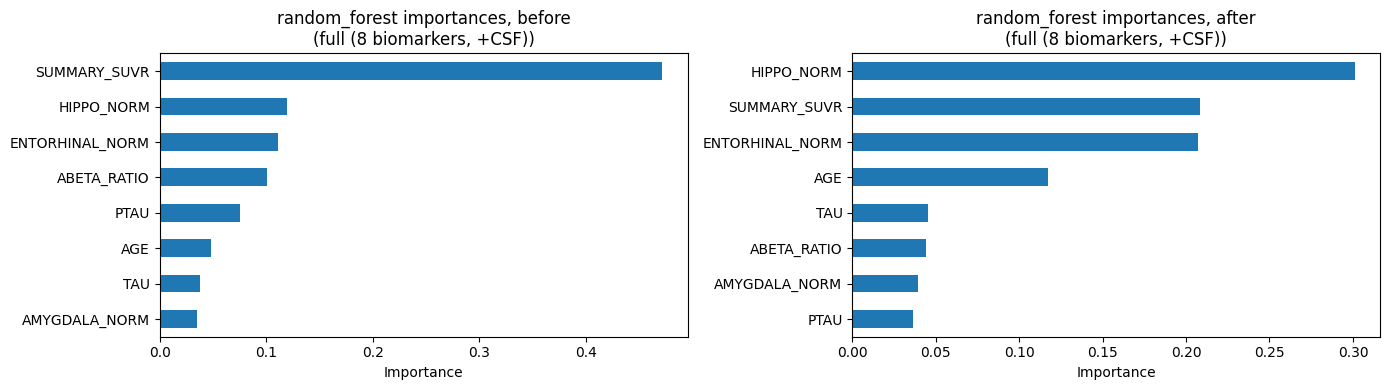

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(figsize[0], figsize[1]))
if len(attribution_before['importances']):
    attribution_before['importances'].sort_values().plot.barh(ax=axes[0])
axes[0].set_title(f"random_forest importances, before\n({attribution_before['tier']})")
axes[0].set_xlabel('Importance')

if len(attribution_after['importances']):
    attribution_after['importances'].sort_values().plot.barh(ax=axes[1])
axes[1].set_title(f"random_forest importances, after\n({attribution_after['tier']})")
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()


**Reading this**: check the tier named in each subplot's title first. If `before` and
`after` landed on different tiers, the CSF free fallback triggering on only one side, the two bars
are two separate fits, not a before and after shift in what the model leans on.

A large negative `after` R&sup2; is expected here and is not automatically a sign chaining made
attribution worse. `RISK_SCORE_AFTER` is hazard_model_1's raw single visit probability, structurally
concentrated near zero the way its 8.3 percent event rate implies, not a smoothly spread score the
way the placeholder is. A regressor has very little variance left to explain once the target is
that concentrated, and on a test fold this small, that alone is enough to swing R&sup2; sharply
negative from noise. Worth reporting as a scale mismatch between the two RISK_SCORE versions, not
smoothed into a single attribution got worse headline.

<a id="sec9"></a>

## 9. Where The Chain Actually Gains

Every section above measures one check in isolation. This section reads sections 4 through 8
together, one row per check, so the presentation has a single table to point at instead of five
scattered ones.


In [23]:
snap_test = snapshot_result[snapshot_result['split'] == 'test']
snap_cost_before = snap_test[snap_test['risk_score'].str.contains('before')]['total_cost'].iloc[0]
snap_cost_after = snap_test[snap_test['risk_score'].str.contains('after')]['total_cost'].iloc[0]
snap_cost_before_ci = snapshot_ci[('test', 'before (placeholder)')]['total_cost']
snap_cost_after_ci = snapshot_ci[('test', 'after (chained)')]['total_cost']

def _cis_overlap(ci_a, ci_b):
    return ci_a[0] <= ci_b[1] and ci_b[0] <= ci_a[1]

snap_cost_overlap_tag = '(overlapping)' if _cis_overlap(snap_cost_before_ci, snap_cost_after_ci) else '(non overlapping)'

attr_before_ci = attribution_ci.get('before (placeholder)')
attr_after_ci = attribution_ci.get('after (chained)')
if attr_before_ci is not None and attr_after_ci is not None:
    attr_overlap_tag = '(overlapping)' if _cis_overlap(attr_before_ci, attr_after_ci) else '(non overlapping)'
    attr_ci_text = (
        f"before CI [{attr_before_ci[0]:.3f}, {attr_before_ci[1]:.3f}], "
        f"after CI [{attr_after_ci[0]:.3f}, {attr_after_ci[1]:.3f}] {attr_overlap_tag}"
    )
else:
    attr_ci_text = 'CI not available for both fits'

summary_rows = [
    {'stage': '1. Point 1 (PCA anomaly score)', 'population': f"{len(gio_common)} of {len(gio_rids)} native",
     'check': 'Mean score, common subset vs. native (section 4)',
     'result': f'{gio_native_pt:.3f} -> {gio_common_pt:.3f}',
     '95% CI': f"native [{gio_native_lo:.3f}, {gio_native_hi:.3f}], "
               f"common [{gio_common_lo:.3f}, {gio_common_hi:.3f}] {gio_mean_overlap_tag}"},
    {'stage': '2. Point 2 (hazard_model_1)', 'population': f"{len(leo_hazard_common)} rows of {len(leo_hazard_out)} native",
     'check': 'AUC, common subset vs. native 0.795 (section 5)',
     'result': f'{leo_common_auc_pt:.3f}' if not pd.isna(leo_common_auc_pt) else 'n/a',
     '95% CI': f"[{leo_common_auc_lo:.3f}, {leo_common_auc_hi:.3f}]" if not pd.isna(leo_common_auc_pt) else 'n/a'},
    {'stage': '2 chained (+ANOMALY_SCORE)', 'population': f"{n_te_a} test rows",
     'check': 'AUC with vs. without ANOMALY_SCORE (section 6)', 'result': f'{auc_without:.3f} -> {auc_with:.3f}'
              if auc_without is not None and auc_with is not None else 'insufficient rows',
     '95% CI': f"without [{auc_without_lo:.3f}, {auc_without_hi:.3f}], "
               f"with [{auc_with_lo:.3f}, {auc_with_hi:.3f}] {anomaly_auc_overlap_tag}"
               if auc_without is not None and auc_with is not None else 'n/a (insufficient rows)'},
    {'stage': '3a. snapshot_adaptive', 'population': f"{len(common_test_full)} test rows",
     'check': 'total_cost, before vs. after chain (section 7)',
     'result': f"{snap_cost_before:.1f} -> {snap_cost_after:.1f}",
     '95% CI': f"before [{snap_cost_before_ci[0]:.1f}, {snap_cost_before_ci[1]:.1f}], "
               f"after [{snap_cost_after_ci[0]:.1f}, {snap_cost_after_ci[1]:.1f}] {snap_cost_overlap_tag}"},
    {'stage': '3b. random_forest attribution', 'population': f"{attribution_after['n_test']} test rows",
     'check': 'R2, before vs. after chain (section 8)',
     'result': f"{attribution_before['r2']:.3f} -> {attribution_after['r2']:.3f}",
     '95% CI': attr_ci_text},
]
summary_df = pd.DataFrame(summary_rows)
summary_df


                            stage  ...                                             95% CI
0  1. Point 1 (PCA anomaly score)  ...  native [1.044, 1.105], common [1.064, 1.139] (...
1     2. Point 2 (hazard_model_1)  ...                                     [0.771, 0.811]
2      2 chained (+ANOMALY_SCORE)  ...  without [0.776, 0.891], with [0.781, 0.892] (o...
3           3a. snapshot_adaptive  ...  before [22065.4, 24902.4], after [12330.9, 147...
4   3b. random_forest attribution  ...  before CI [-0.391, 0.289], after CI [-1.382, 0...

[5 rows x 5 columns]

**One row per check, same population throughout**, reading each already chosen winner's own
before and after gain rather than a new competition between candidates. Where a before and after
number moves with two non overlapping intervals, that is a real, common population effect. Where
the intervals overlap, that is worth reporting as a null result too, not smoothed into a headline
either way.

<a id="sec10"></a>

## 10. Saving Standardized Results


In [24]:
# label here (final_pipeline_before/after) is this section's own row naming
# convention for approach_comparison.csv, distinct from snapshot_ci's key,
# the section 7 before/after (placeholder)/(chained) labels. sec7_label below
# bridges the two so the CI already computed in section 7 is reused here
# rather than recomputed a second time.
for split_name, split_df in [('train', common_train_full), ('test', common_test_full)]:
    for label, col, sec7_label in [
        ('final_pipeline_before', 'RISK_SCORE_BEFORE', 'before (placeholder)'),
        ('final_pipeline_after', 'RISK_SCORE_AFTER', 'after (chained)'),
    ]:
        cost, didi, catch, n = evaluate_snapshot(split_df, col)
        ci = snapshot_ci[(split_name, sec7_label)]
        du.append_approach_result(
            RESULTS_DIR, approach=label, approach_group='interval_policy',
            split=split_name, n_rows=n, total_cost=cost, didi=didi, catch_rate=catch,
            ci={'total_cost': ci['total_cost'], 'didi': ci['didi'], 'catch_rate': ci['catch_rate']},
            notes=f'snapshot_adaptive on the common Point 1/Point 2/final.csv subset ({len(common_rids)} patients), '
                  f'{"placeholder RISK_SCORE" if "before" in label else "chained with Point 2 hazard_model_1 + Point 1 ANOMALY_SCORE"}.',
        )

for label, risk_col, res, sec8_label in [
    ('final_pipeline_attribution_before', 'RISK_SCORE_BEFORE', attribution_before, 'before (placeholder)'),
    ('final_pipeline_attribution_after', 'RISK_SCORE_AFTER', attribution_after, 'after (chained)'),
]:
    r2_ci = attribution_ci.get(sec8_label)
    du.append_approach_result(
        RESULTS_DIR, approach=label, approach_group='attribution',
        split='test', n_rows=res['n_test'], r2=res['r2'], mae=res['mae'],
        ci={'r2': r2_ci} if r2_ci is not None else None,
        notes=f'random_forest attribution on the common subset, '
              f'{"placeholder RISK_SCORE" if "before" in label else "chained RISK_SCORE"}.',
    )

print("Appended to results/decision_support/approach_comparison.csv, with 95% bootstrap CIs on")
print("every metric. comparison.ipynb will pick these rows up automatically on its next run,")
print("same shared file every approach_*.ipynb uses.")


Appended to results/decision_support/approach_comparison.csv, with 95% bootstrap CIs on
every metric. comparison.ipynb will pick these rows up automatically on its next run,
same shared file every approach_*.ipynb uses.


<a id="sec11"></a>

## 11. Takeaways

**What this notebook adds**: hazard_model_1 as a real, exported per patient signal, chained into
this pipeline for the first time, and all four already chosen winners, PCA's anomaly score,
hazard_model_1, snapshot_adaptive, random_forest attribution, validated together on one explicitly
computed common patient subset rather than each read off its own, differently sized native
population. None of the four original model selection comparisons are repeated here.

**What is real, stated plainly**: on the test split, snapshot_adaptive's total_cost drop, 23,498.8
to 13,475.3, and its DIDI rise, 1.081 to 2.573, both have non overlapping before and after
intervals. The chain is a genuine cost win bought at a genuine fairness cost, not a wash either way.
Its catch_rate drop, 98.8% to 93.1%, sits right at the edge, the two intervals almost but not quite
touch.

**What is not yet distinguishable from noise**: random_forest attribution's R&sup2;, 0.042 before
chaining to minus 0.187 after, and hazard_model_1's AUC gain from the anomaly score, 0.836 to
0.838, both have heavily overlapping before and after intervals, on 85 and 616 test rows
respectively. The honest reading for both is too little signal on this test fold to call a
direction, not a proven negative and not a confirmed win.

**What is still open**: exporting hazard_model_1's per patient score directly from
`leo/rul_hazard/hazard_model_1.py` itself, a few lines added to its own `main()`, rather than only
computing it here.
